In [ ]:
!pip install ultralytics timm opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.9 MB/s eta 0:00:00


In [ ]:
import torch
import cv2
import numpy as np
from ultralytics import YOLO
import timm
from torchvision import transforms
from PIL import Image
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
yolo_model = YOLO("/content/best (1).pt")

In [ ]:
import torch
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 101

vit_model = timm.create_model(
    "vit_tiny_patch16_224.augreg_in21k",
    pretrained=False,
    num_classes=NUM_CLASSES
)

state_dict = torch.load("/content/vit_tiny_food_models - Copy.pth", map_location=device)

# remove prefix
new_state_dict = {k.replace("timm_model.", ""): v for k, v in state_dict.items()}

vit_model.load_state_dict(new_state_dict)
vit_model.to(device)
vit_model.eval()

print("ViT model loaded successfully")

ViT model loaded successfully


In [ ]:
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.eval()

transform_depth = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 90.8MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [ ]:
import torch
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load model
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.to(device)
midas.eval()

# load transform
transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

# load image
img = cv2.imread("/content/1000112289.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# transform
input_batch = transform(img).to(device)

# inference
with torch.no_grad():
    prediction = midas(input_batch)

depth_map = prediction.squeeze().cpu().numpy()

depth_map = cv2.resize(
    depth_map,
    (image.shape[1], image.shape[0])  # width, height
)

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [ ]:
input_batch = transform_depth(image_rgb).to(device)

with torch.no_grad():
    depth_prediction = midas(input_batch)

depth_map = prediction.squeeze().cpu().numpy()

# resize depth map to match original image
depth_map = cv2.resize(depth_map, (image.shape[1], image.shape[0]))

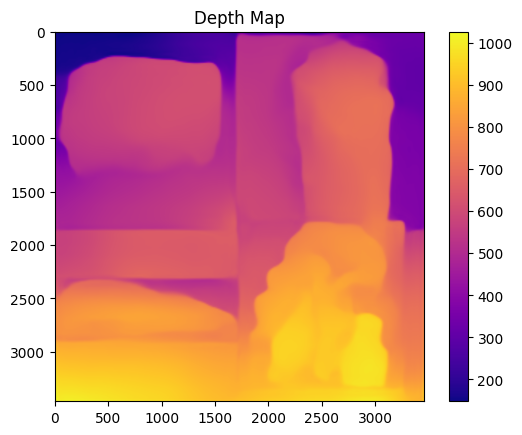

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(depth_map, cmap="plasma")
plt.colorbar()
plt.title("Depth Map")
plt.show()

In [ ]:
results = yolo_model(image, conf=0.4)


0: 640x640 4 foods, 7.3ms
Speed: 5.5ms preprocess, 7.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
boxes = results[0].boxes.xyxy.cpu().numpy()
confidences = results[0].boxes.conf.cpu().numpy()

In [ ]:
for box in boxes:
    x1, y1, x2, y2 = map(int, box)

    depth_region = depth_map[y1:y2, x1:x2]
    avg_depth = depth_region.mean()

    print("Average depth:", avg_depth)

Average depth: 834.6891
Average depth: 513.1398
Average depth: 740.4816
Average depth: 595.87305


In [ ]:
CLASS_NAMES = [
"apple_pie","baby_back_ribs","baklava","beef_carpaccio","beef_tartare",
"beet_salad","beignets","bibimbap","bread_pudding","breakfast_burrito",
"bruschetta","caesar_salad","cannoli","caprese_salad","carrot_cake",
"ceviche","cheese_plate","cheesecake","chicken_curry","chicken_quesadilla",
"chicken_wings","chocolate_cake","chocolate_mousse","churros","clam_chowder",
"club_sandwich","crab_cakes","creme_brulee","croque_madame","cup_cakes",
"deviled_eggs","donuts","dumplings","edamame","eggs_benedict","escargots",
"falafel","filet_mignon","fish_and_chips","foie_gras","french_fries",
"french_onion_soup","french_toast","fried_calamari","fried_rice",
"frozen_yogurt","garlic_bread","gnocchi","greek_salad","grilled_cheese_sandwich",
"grilled_salmon","guacamole","gyoza","hamburger","hot_and_sour_soup",
"hot_dog","huevos_rancheros","hummus","ice_cream","lasagna","lobster_bisque",
"lobster_roll_sandwich","macaroni_and_cheese","macarons","miso_soup",
"mussels","nachos","omelette","onion_rings","oysters","pad_thai",
"paella","pancakes","panna_cotta","peking_duck","pho","pizza",
"pork_chop","poutine","prime_rib","pulled_pork_sandwich","ramen",
"ravioli","red_velvet_cake","risotto","samosa","sashimi","scallops",
"seaweed_salad","shrimp_and_grits","spaghetti_bolognese","spaghetti_carbonara",
"spring_rolls","steak","strawberry_shortcake","sushi","tacos","takoyaki",
"tiramisu","tuna_tartare","waffles"
]

In [ ]:
def classify_food(crop):

    crop = Image.fromarray(crop)

    input_tensor = vit_transform(crop).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vit_model(input_tensor)

    pred = torch.argmax(outputs, dim=1).item()

    return CLASS_NAMES[pred]

In [ ]:
vit_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
FOOD_DENSITY = {
"apple_pie":0.75,
"baby_back_ribs":1.05,
"baklava":0.75,
"beef_carpaccio":1.05,
"beef_tartare":1.05,
"beet_salad":0.95,
"beignets":0.60,
"bibimbap":0.95,
"bread_pudding":0.75,
"breakfast_burrito":0.95,
"bruschetta":0.85,
"caesar_salad":0.90,
"cannoli":0.70,
"caprese_salad":0.90,
"carrot_cake":0.70,
"ceviche":1.00,
"cheese_plate":1.05,
"cheesecake":0.80,
"chicken_curry":1.00,
"chicken_quesadilla":0.95,
"chicken_wings":1.05,
"chocolate_cake":0.70,
"chocolate_mousse":0.50,
"churros":0.65,
"clam_chowder":1.00,
"club_sandwich":0.95,
"crab_cakes":1.00,
"creme_brulee":1.00,
"croque_madame":1.05,
"cup_cakes":0.65,
"deviled_eggs":1.05,
"donuts":0.60,
"dumplings":0.95,
"edamame":1.00,
"eggs_benedict":1.05,
"escargots":1.05,
"falafel":0.90,
"filet_mignon":1.05,
"fish_and_chips":1.00,
"foie_gras":1.05,
"french_fries":0.60,
"french_onion_soup":1.00,
"french_toast":0.80,
"fried_calamari":0.90,
"fried_rice":0.95,
"frozen_yogurt":0.60,
"garlic_bread":0.70,
"gnocchi":0.95,
"greek_salad":0.90,
"grilled_cheese_sandwich":0.90,
"grilled_salmon":1.05,
"guacamole":0.95,
"gyoza":0.95,
"hamburger":0.95,
"hot_and_sour_soup":1.00,
"hot_dog":0.95,
"huevos_rancheros":1.05,
"hummus":0.95,
"ice_cream":0.60,
"lasagna":0.95,
"lobster_bisque":1.00,
"lobster_roll_sandwich":0.95,
"macaroni_and_cheese":0.90,
"macarons":0.55,
"miso_soup":1.00,
"mussels":1.05,
"nachos":0.70,
"omelette":1.05,
"onion_rings":0.65,
"oysters":1.05,
"pad_thai":0.95,
"paella":0.95,
"pancakes":0.70,
"panna_cotta":0.95,
"peking_duck":1.05,
"pho":1.00,
"pizza":0.85,
"pork_chop":1.05,
"poutine":0.95,
"prime_rib":1.05,
"pulled_pork_sandwich":0.95,
"ramen":1.00,
"ravioli":0.95,
"red_velvet_cake":0.70,
"risotto":0.95,
"samosa":0.85,
"sashimi":1.05,
"scallops":1.05,
"seaweed_salad":0.90,
"shrimp_and_grits":0.95,
"spaghetti_bolognese":0.95,
"spaghetti_carbonara":0.95,
"spring_rolls":0.85,
"steak":1.05,
"strawberry_shortcake":0.70,
"sushi":0.90,
"tacos":0.90,
"takoyaki":0.85,
"tiramisu":0.75,
"tuna_tartare":1.05,
"waffles":0.70
}

In [ ]:
scale = 1e-7

for box in boxes:

    x1,y1,x2,y2 = map(int,box)

    crop = image_rgb[y1:y2,x1:x2]

    label = classify_food(crop)

    depth_region = depth_map[y1:y2,x1:x2]
    avg_depth = depth_region.mean()

    area = (x2-x1)*(y2-y1)

    volume = area * avg_depth

    density = FOOD_DENSITY.get(label,1.0)

    grams = volume * density * scale

    print(label,"≈",int(grams),"grams")

chicken_wings ≈ 183 grams
croque_madame ≈ 110 grams
baklava ≈ 50 grams
cannoli ≈ 83 grams


In [ ]:
import numpy as np

class PortionCalibrator:

    def __init__(self):
        self.volumes = []
        self.weights = []

    def update(self, volume, real_weight):
        self.volumes.append(volume)
        self.weights.append(real_weight)

    def get_scale(self):
        if len(self.volumes) == 0:
            return 1e-5   # default value

        v = np.array(self.volumes)
        w = np.array(self.weights)

        return np.mean(w / v)

In [ ]:
calibrator = PortionCalibrator()

In [ ]:
calibrator.update(volume, real_weight)

In [ ]:
!pip install ultralytics timm opencv-python matplotlib -q

In [ ]:
import torch
import cv2
import numpy as np
import timm
from ultralytics import YOLO
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
yolo_model = YOLO("/content/best (1).pt")

In [ ]:
NUM_CLASSES = 101

vit_model = timm.create_model(
    "vit_tiny_patch16_224.augreg_in21k",
    pretrained=False,
    num_classes=NUM_CLASSES
)

state_dict = torch.load("/content/vit_tiny_food_models - Copy.pth", map_location=device)

new_state_dict = {k.replace("timm_model.", ""): v for k, v in state_dict.items()}

vit_model.load_state_dict(new_state_dict)
vit_model.to(device)
vit_model.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [ ]:
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.to(device)
midas.eval()

depth_transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


In [ ]:
vit_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [ ]:
CLASS_NAMES = [
"apple_pie","baby_back_ribs","baklava","beef_carpaccio","beef_tartare",
"beet_salad","beignets","bibimbap","bread_pudding","breakfast_burrito",
"bruschetta","caesar_salad","cannoli","caprese_salad","carrot_cake",
"ceviche","cheese_plate","cheesecake","chicken_curry","chicken_quesadilla",
"chicken_wings","chocolate_cake","chocolate_mousse","churros","clam_chowder",
"club_sandwich","crab_cakes","creme_brulee","croque_madame","cup_cakes",
"deviled_eggs","donuts","dumplings","edamame","eggs_benedict","escargots",
"falafel","filet_mignon","fish_and_chips","foie_gras","french_fries",
"french_onion_soup","french_toast","fried_calamari","fried_rice",
"frozen_yogurt","garlic_bread","gnocchi","greek_salad","grilled_cheese_sandwich",
"grilled_salmon","guacamole","gyoza","hamburger","hot_and_sour_soup",
"hot_dog","huevos_rancheros","hummus","ice_cream","lasagna","lobster_bisque",
"lobster_roll_sandwich","macaroni_and_cheese","macarons","miso_soup",
"mussels","nachos","omelette","onion_rings","oysters","pad_thai",
"paella","pancakes","panna_cotta","peking_duck","pho","pizza",
"pork_chop","poutine","prime_rib","pulled_pork_sandwich","ramen",
"ravioli","red_velvet_cake","risotto","samosa","sashimi","scallops",
"seaweed_salad","shrimp_and_grits","spaghetti_bolognese","spaghetti_carbonara",
"spring_rolls","steak","strawberry_shortcake","sushi","tacos","takoyaki",
"tiramisu","tuna_tartare","waffles"
]

In [ ]:
def classify_food(crop):

    crop = Image.fromarray(crop)

    input_tensor = vit_transform(crop).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = vit_model(input_tensor)

    pred = torch.argmax(outputs, dim=1).item()

    return CLASS_NAMES[pred]

In [ ]:
def process_image(image_path):

    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Depth estimation
    input_batch = depth_transform(image_rgb).to(device)

    with torch.no_grad():
        prediction = midas(input_batch)

    depth_map = prediction.squeeze().cpu().numpy()
    depth_map = cv2.resize(depth_map,(image.shape[1],image.shape[0]))

    # YOLO detection
    results = yolo_model(image,conf=0.4)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    scale = 1e-6

    for box in boxes:

        x1,y1,x2,y2 = map(int,box)

        crop = image_rgb[y1:y2,x1:x2]

        label = classify_food(crop)

        depth_region = depth_map[y1:y2,x1:x2]
        avg_depth = depth_region.mean()

        area = (x2-x1)*(y2-y1)

        volume = area*avg_depth

        density = FOOD_DENSITY.get(label,1.0)

        grams = volume*density*scale

        print(label,"≈",int(grams),"grams")

In [ ]:
process_image("/content/apple_pie.png")


0: 480x640 1 food, 6.6ms
Speed: 2.3ms preprocess, 6.6ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
gyoza ≈ 36 grams


In [ ]:
process_image("/content/Screenshot 2026-03-07 205613.png")


0: 608x640 1 food, 9.5ms
Speed: 2.5ms preprocess, 9.5ms inference, 1.4ms postprocess per image at shape (1, 3, 608, 640)
apple_pie ≈ 95 grams


In [ ]:
process_image("/content/Screenshot 2026-03-07 205824.png")


0: 480x640 1 food, 9.2ms
Speed: 2.3ms preprocess, 9.2ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)
apple_pie ≈ 23 grams


In [ ]:
process_image("/content/Screenshot 2026-03-07 210128.png")


0: 480x640 1 food, 8.3ms
Speed: 2.8ms preprocess, 8.3ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
baby_back_ribs ≈ 188 grams


In [ ]:
process_image("/content/Screenshot 2026-03-07 210543.png")


0: 352x640 2 foods, 39.5ms
Speed: 3.6ms preprocess, 39.5ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)
macarons ≈ 30 grams
cheesecake ≈ 45 grams
